In [12]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage
from dotenv import load_dotenv

load_dotenv()

llm = ChatOpenAI(model='gpt-4o-mini')

class StateMap(TypedDict):
    messages : Annotated[List[BaseMessage], add_messages]
    counter : int

def chat_bot(state):
    response = llm.invoke(state['messages'])
    print("==== CHATBOT======")
    print(f'=========RESPONSE========== \n{response}')
    print(f'\n\n==========STATE===========\n{state}')
    return {
        "messages": [response],
        "counter": 1
    }




graph = StateGraph(StateMap)


graph.add_node("chat_bot", chat_bot)
graph.add_edge(START, "chat_bot")
graph.add_edge("chat_bot", END)

app = graph.compile()

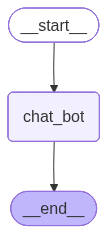

In [13]:
app

In [14]:
response = app.invoke({
    "messages":[HumanMessage(content="Write a 3 line poem on cats")],
    "counter": 0
})

print("====FINAL RESPONSE=======")
print(response)

==== CHATBOT======
=========RESPONSE========== 
content='Whiskers twitch in moonlit grace,  \nSilent paws embrace the night,  \nFeline dreams in shadows trace.  ' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 15, 'total_tokens': 40, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e738e3044b', 'id': 'chatcmpl-DPuUXzvLAk1zb2zz2bqhhdY1JFGva', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019d4a48-0488-7c83-8cab-6d1a4d429f42-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 15, 'output_tokens': 25, 'total_tokens': 40, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 

In [17]:
print('POEM \n',response["messages"][-1].content)
print('Counter: ',response.get('counter',0))

POEM 
 Whiskers twitch in moonlit grace,  
Silent paws embrace the night,  
Feline dreams in shadows trace.  
Counter:  1
